<a href="https://colab.research.google.com/github/amzad-786githumb/Privacy-Preserving-Synthetic-Tabular-Data-Generation-Using-Generative-Adversarial-Networks/blob/main/03_Statistical_Module.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip -q install sdv==1.12.0
!pip -q install copulas
!pip -q install sdmetrics
!pip -q install scipy
!pip -q install seaborn
!pip -q install networkx

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.2

The `ValueError` occurs due to an incompatibility between the installed `numpy` version and `pandas`. To resolve this, we need to force re-install `numpy` and `pandas` to ensure compatible versions are used.

In [2]:
# Force reinstall numpy and pandas to resolve version incompatibility
!pip uninstall numpy pandas -y
!pip install numpy pandas --upgrade --force-reinstall

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: pandas 2.3.3
Uninstalling pandas-2.3.3:
  Successfully uninstalled pandas-2.3.3
  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
Using cached pandas-3.0.3-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (10.9 MB)
Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl (229 kB)
Using cached six-1.17.0-py2.py3-none-any.whl (11 kB)
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Suc

After executing the above cell, please re-run the 'Import Libraries' cell (`5xdOjxw2Aydl`) to ensure the newly installed packages are used.

In [1]:
# ============================================================
# Import Libraries
# ============================================================

import os
import random
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from scipy.stats import skew
from scipy.stats import kurtosis

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer
from sdv.single_table import CopulaGANSynthesizer
from sdv.single_table import TVAESynthesizer

warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# ============================================================
# Project Configuration
# ============================================================

PROJECT = "/content/SPP_GAN_Project"

DATA_PATH = os.path.join(
    PROJECT,
    "datasets",
    "processed"
)

MODEL_PATH = os.path.join(
    PROJECT,
    "models",
    "statistical"
)

RESULT_PATH = os.path.join(
    PROJECT,
    "results",
    "statistical"
)

for path in [

    DATA_PATH,

    MODEL_PATH,

    RESULT_PATH

]:

    os.makedirs(

        path,

        exist_ok=True

    )

print(PROJECT)

/content/SPP_GAN_Project


In [3]:
# ============================================================
# Load Processed Datasets
# ============================================================

adult_df = pd.read_csv(

    os.path.join(

        DATA_PATH,

        "adult_income_processed.csv"

    )

)

bank_df = pd.read_csv(

    os.path.join(

        DATA_PATH,

        "bank_marketing_processed.csv"

    )

)

breast_df = pd.read_csv(

    os.path.join(

        DATA_PATH,

        "breast_cancer_processed.csv"

    )

)

datasets = {

    "Adult Income":adult_df,

    "Bank Marketing":bank_df,

    "Breast Cancer":breast_df

}

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [4]:
# ============================================================
# Random Seed
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

print("Seed:",SEED)

Seed: 42


In [5]:
# ============================================================
# Load Processed Datasets
# ============================================================

adult_df = pd.read_csv(

    os.path.join(

        DATA_PATH,

        "adult_income_processed.csv"

    )

)

bank_df = pd.read_csv(

    os.path.join(

        DATA_PATH,

        "bank_marketing_processed.csv"

    )

)

breast_df = pd.read_csv(

    os.path.join(

        DATA_PATH,

        "breast_cancer_processed.csv"

    )

)

datasets = {

    "Adult Income":adult_df,

    "Bank Marketing":bank_df,

    "Breast Cancer":breast_df

}

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [6]:
# ============================================================
# Dataset Verification
# ============================================================

for name,df in datasets.items():

    print("="*60)

    print(name)

    print("="*60)

    print("Shape :",df.shape)

    print("Missing :",df.isnull().sum().sum())

    print("Duplicates :",df.duplicated().sum())

    print()

Adult Income
Shape : (5, 13)
Missing : 0
Duplicates : 0

Bank Marketing
Shape : (5, 21)
Missing : 0
Duplicates : 0

Breast Cancer
Shape : (5, 6)
Missing : 0
Duplicates : 0



In [7]:
# ============================================================
# Metadata Detection
# ============================================================

metadata = {}

for name,df in datasets.items():

    meta = SingleTableMetadata()

    meta.detect_from_dataframe(df)

    metadata[name] = meta

print("Metadata Generated Successfully")

Metadata Generated Successfully


In [10]:
# ============================================================
# Metadata Summary
# ============================================================

for name,meta in metadata.items():

    print("="*60)

    print(name)

    print("="*60)

    print(meta.to_dict())

    print()

Adult Income
{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1', 'columns': {'age': {'sdtype': 'numerical'}, 'workclass': {'sdtype': 'categorical'}, 'education': {'sdtype': 'categorical'}, 'marital_status': {'sdtype': 'categorical'}, 'occupation': {'sdtype': 'categorical'}, 'relationship': {'sdtype': 'categorical'}, 'race': {'sdtype': 'categorical'}, 'sex': {'sdtype': 'categorical'}, 'capital_gain': {'sdtype': 'numerical'}, 'capital_loss': {'sdtype': 'numerical'}, 'hours_per_week': {'sdtype': 'numerical'}, 'native_country': {'sdtype': 'categorical'}, 'income': {'sdtype': 'categorical'}}}

Bank Marketing
{'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1', 'columns': {'age': {'sdtype': 'numerical'}, 'job': {'sdtype': 'categorical'}, 'marital': {'sdtype': 'categorical'}, 'education': {'sdtype': 'categorical'}, 'default': {'sdtype': 'categorical'}, 'housing': {'sdtype': 'categorical'}, 'loan': {'sdtype': 'categorical'}, 'contact': {'sdtype': 'categorical'}, 'month': {'sdtype': 'categorical'}, 'day_of_we

In [8]:
# ============================================================
# Feature Types
# ============================================================

feature_summary=[]

for name,df in datasets.items():

    feature_summary.append({

        "Dataset":name,

        "Rows":len(df),

        "Columns":df.shape[1],

        "Numerical":

        len(df.select_dtypes(

            include=["int64","float64"]

        ).columns),

        "Categorical":

        len(df.select_dtypes(

            include=["object","category"]

        ).columns)

    })

feature_summary=pd.DataFrame(feature_summary)

display(feature_summary)

,Dataset,Rows,Columns,Numerical,Categorical
0,Adult Income,5,13,4,9
1,Bank Marketing,5,21,10,11
2,Breast Cancer,5,6,6,0


In [9]:
# ============================================================
# Dataset Information
# ============================================================

for name,df in datasets.items():

    print("="*70)

    print(name)

    print("="*70)

    display(df.head())

    display(df.describe(include="all"))

Adult Income


,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,30,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,2174,0,40,United-States,<=50K
1,45,Self-emp-not-inc,HS-grad,Divorced,Craft-repair,Not-in-family,Black,Female,0,0,50,United-States,>50K
2,25,Private,Some-college,Never-married,Adm-clerical,Own-child,White,Female,0,0,38,United-States,<=50K
3,50,Federal-gov,Bachelors,Married-civ-spouse,Exec-managerial,Wife,Asian-Pac-Islander,Male,7688,0,40,China,>50K
4,35,Local-gov,Masters,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,45,United-States,<=50K


,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
count,5.000000,5,5,5,5,5,5,5,5.000000,5.0,5.000000,5,5
unique,NaN,4,4,3,4,4,3,2,NaN,NaN,NaN,2,2
top,NaN,Private,Bachelors,Married-civ-spouse,Exec-managerial,Not-in-family,White,Female,NaN,NaN,NaN,United-States,<=50K
freq,NaN,2,2,2,2,2,3,3,NaN,NaN,NaN,4,3
mean,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1972.400000,0.0,42.600000,NaN,NaN
std,10.368221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3330.908705,0.0,4.878524,NaN,NaN
min,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,38.000000,NaN,NaN
25%,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,40.000000,NaN,NaN
50%,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,40.000000,NaN,NaN
75%,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2174.000000,0.0,45.000000,NaN,NaN


Bank Marketing


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,40,admin.,married,basic.9y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,42,technician,married,professional.course,no,yes,no,cellular,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,yes,cellular,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,5.000000,5,5,5,5,5,5,5,5,5,...,5.0,5.0,5.0,5,5.0,5.000,5.0,5.000,5.0,5
unique,NaN,4,1,4,1,2,2,2,1,1,...,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,1
top,NaN,services,married,high.school,no,yes,no,telephone,may,mon,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,2,5,2,5,4,4,3,5,5,...,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,5
mean,46.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN
std,9.121403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.000,0.0,0.000,0.0,NaN
min,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN
25%,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN
50%,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN
75%,56.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN


Breast Cancer


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,131.20,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,1
4,20.29,14.34,135.10,1297.0,0.10030,0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,diagnosis
count,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000
mean,17.992000,16.824000,119.33600,1042.620000,0.111108,0.200000
std,3.807929,4.495134,23.76206,388.421771,0.021523,0.447214
min,11.420000,10.380000,77.58000,386.100000,0.084740,0.000000
25%,17.990000,14.340000,122.80000,1001.000000,0.100300,0.000000
50%,19.690000,17.770000,130.00000,1203.000000,0.109600,0.000000
75%,20.290000,20.380000,131.20000,1297.000000,0.118400,0.000000
max,20.570000,21.250000,135.10000,1326.000000,0.142500,1.000000


In [10]:
# ============================================================
# Save Metadata
# ============================================================

for name,meta in metadata.items():

    filename=name.lower().replace(" ","_")+"_metadata.json"

    meta.save_to_json(

        os.path.join(

            MODEL_PATH,

            filename

        )

    )

print("Metadata Saved Successfully")

ValueError: A file named 'adult_income_metadata.json' already exists in this folder. Please specify a different filename.

In [11]:
import os
from sdv.metadata import SingleTableMetadata

# ============================================================
# Save Metadata
# ============================================================

for name, meta in metadata.items():
    filename = name.lower().replace(" ", "_") + "_metadata.json"
    filepath = os.path.join(MODEL_PATH, filename)

    # Check if the file already exists and remove it to prevent ValueError
    if os.path.exists(filepath):
        os.remove(filepath)

    meta.save_to_json(
        filepath
    )

print("Metadata Saved Successfully")

Metadata Saved Successfully


In [12]:
# ============================================================
# Summary Report
# ============================================================

summary=[]

for name,df in datasets.items():

    summary.append({

        "Dataset":name,

        "Rows":df.shape[0],

        "Columns":df.shape[1],

        "Memory(MB)":round(

            df.memory_usage().sum()/1024**2,

            2

        )

    })

summary=pd.DataFrame(summary)

display(summary)

,Dataset,Rows,Columns,Memory(MB)
0,Adult Income,5,13,0.0
1,Bank Marketing,5,21,0.0
2,Breast Cancer,5,6,0.0


In [13]:
summary.to_csv(

    os.path.join(

        RESULT_PATH,

        "dataset_summary.csv"

    ),

    index=False

)

In [14]:
print("="*70)

print("Statistical Module Initialization Completed")

print("="*70)

print()

print("Datasets")

for name in datasets.keys():

    print("✓",name)

print()

print("Metadata Generated")

print("Summary Report Saved")

print("Ready for Statistical Analysis")

Statistical Module Initialization Completed

Datasets
✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer

Metadata Generated
Summary Report Saved
Ready for Statistical Analysis


In [15]:
# ============================================================
# Statistical Analysis Libraries
# ============================================================

from scipy.stats import shapiro
from scipy.stats import normaltest
from scipy.stats import skew
from scipy.stats import kurtosis

import seaborn as sns

print("Statistical Libraries Loaded")

Statistical Libraries Loaded


In [16]:
# ============================================================
# Descriptive Statistics
# ============================================================

statistics = {}

for name, df in datasets.items():

    statistics[name] = df.describe(include="all").T

    print("="*70)
    print(name)
    print("="*70)

    display(statistics[name])

Adult Income


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,5.0,NaN,NaN,NaN,37.0,10.368221,25.0,30.0,35.0,45.0,50.0
workclass,5,4,Private,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,5,4,Bachelors,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,5,3,Married-civ-spouse,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,5,4,Exec-managerial,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,5,4,Not-in-family,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,5,3,White,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,5,2,Female,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
capital_gain,5.0,NaN,NaN,NaN,1972.4,3330.908705,0.0,0.0,0.0,2174.0,7688.0
capital_loss,5.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Bank Marketing


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,5.0,NaN,NaN,NaN,46.2,9.121403,37.0,40.0,42.0,56.0,56.0
job,5,4,services,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,5,1,married,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,5,4,high.school,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,5,1,no,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,5,2,yes,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,5,2,no,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,5,2,telephone,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,5,1,may,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,5,1,mon,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Breast Cancer


,count,mean,std,min,25%,50%,75%,max
mean radius,5.0,17.992000,3.807929,11.42000,17.9900,19.6900,20.2900,20.5700
mean texture,5.0,16.824000,4.495134,10.38000,14.3400,17.7700,20.3800,21.2500
mean perimeter,5.0,119.336000,23.762060,77.58000,122.8000,130.0000,131.2000,135.1000
mean area,5.0,1042.620000,388.421771,386.10000,1001.0000,1203.0000,1297.0000,1326.0000
mean smoothness,5.0,0.111108,0.021523,0.08474,0.1003,0.1096,0.1184,0.1425
diagnosis,5.0,0.200000,0.447214,0.00000,0.0000,0.0000,0.0000,1.0000


In [17]:
# ============================================================
# Missing Values Summary
# ============================================================

missing_report=[]

for name,df in datasets.items():

    missing_report.append({

        "Dataset":name,

        "Missing Values":df.isnull().sum().sum(),

        "Duplicates":df.duplicated().sum()

    })

missing_report=pd.DataFrame(missing_report)

display(missing_report)

,Dataset,Missing Values,Duplicates
0,Adult Income,0,0
1,Bank Marketing,0,0
2,Breast Cancer,0,0


In [18]:
# ============================================================
# Numerical Feature Statistics
# ============================================================

numerical_summary=[]

for name,df in datasets.items():

    num=df.select_dtypes(include=["int64","float64"])

    numerical_summary.append({

        "Dataset":name,

        "Features":num.shape[1],

        "Mean":round(num.mean().mean(),4),

        "Std":round(num.std().mean(),4),

        "Min":round(num.min().min(),4),

        "Max":round(num.max().max(),4)

    })

numerical_summary=pd.DataFrame(numerical_summary)

display(numerical_summary)

,Dataset,Features,Mean,Std,Min,Max
0,Adult Income,4,513.0000,836.5389,0.0,7688.0
1,Bank Marketing,10,652.9351,6.8622,-36.4,5191.0
2,Breast Cancer,6,199.5139,70.1593,0.0,1326.0


In [19]:
# ============================================================
# Skewness & Kurtosis
# ============================================================

shape_report=[]

for name,df in datasets.items():

    num=df.select_dtypes(include=["int64","float64"])

    for col in num.columns:

        shape_report.append({

            "Dataset":name,

            "Feature":col,

            "Skewness":round(skew(num[col]),3),

            "Kurtosis":round(kurtosis(num[col]),3)

        })

shape_report=pd.DataFrame(shape_report)

display(shape_report.head())

,Dataset,Feature,Skewness,Kurtosis
0,Adult Income,age,0.158,-1.491
1,Adult Income,capital_gain,1.238,-0.175
2,Adult Income,capital_loss,NaN,NaN
3,Adult Income,hours_per_week,0.690,-1.030
4,Bank Marketing,age,0.291,-1.763


In [20]:
# ============================================================
# Normality Test
# ============================================================

normality=[]

for name,df in datasets.items():

    num=df.select_dtypes(include=["int64","float64"])

    for col in num.columns:

        if len(num[col])<=5000:

            p=shapiro(num[col])[1]

        else:

            p=normaltest(num[col])[1]

        normality.append({

            "Dataset":name,

            "Feature":col,

            "P-value":round(p,5),

            "Normal":

            "Yes" if p>0.05 else "No"

        })

normality=pd.DataFrame(normality)

display(normality.head())

,Dataset,Feature,P-value,Normal
0,Adult Income,age,0.75397,Yes
1,Adult Income,capital_gain,0.01377,No
2,Adult Income,capital_loss,1.00000,Yes
3,Adult Income,hours_per_week,0.33590,Yes
4,Bank Marketing,age,0.11080,Yes


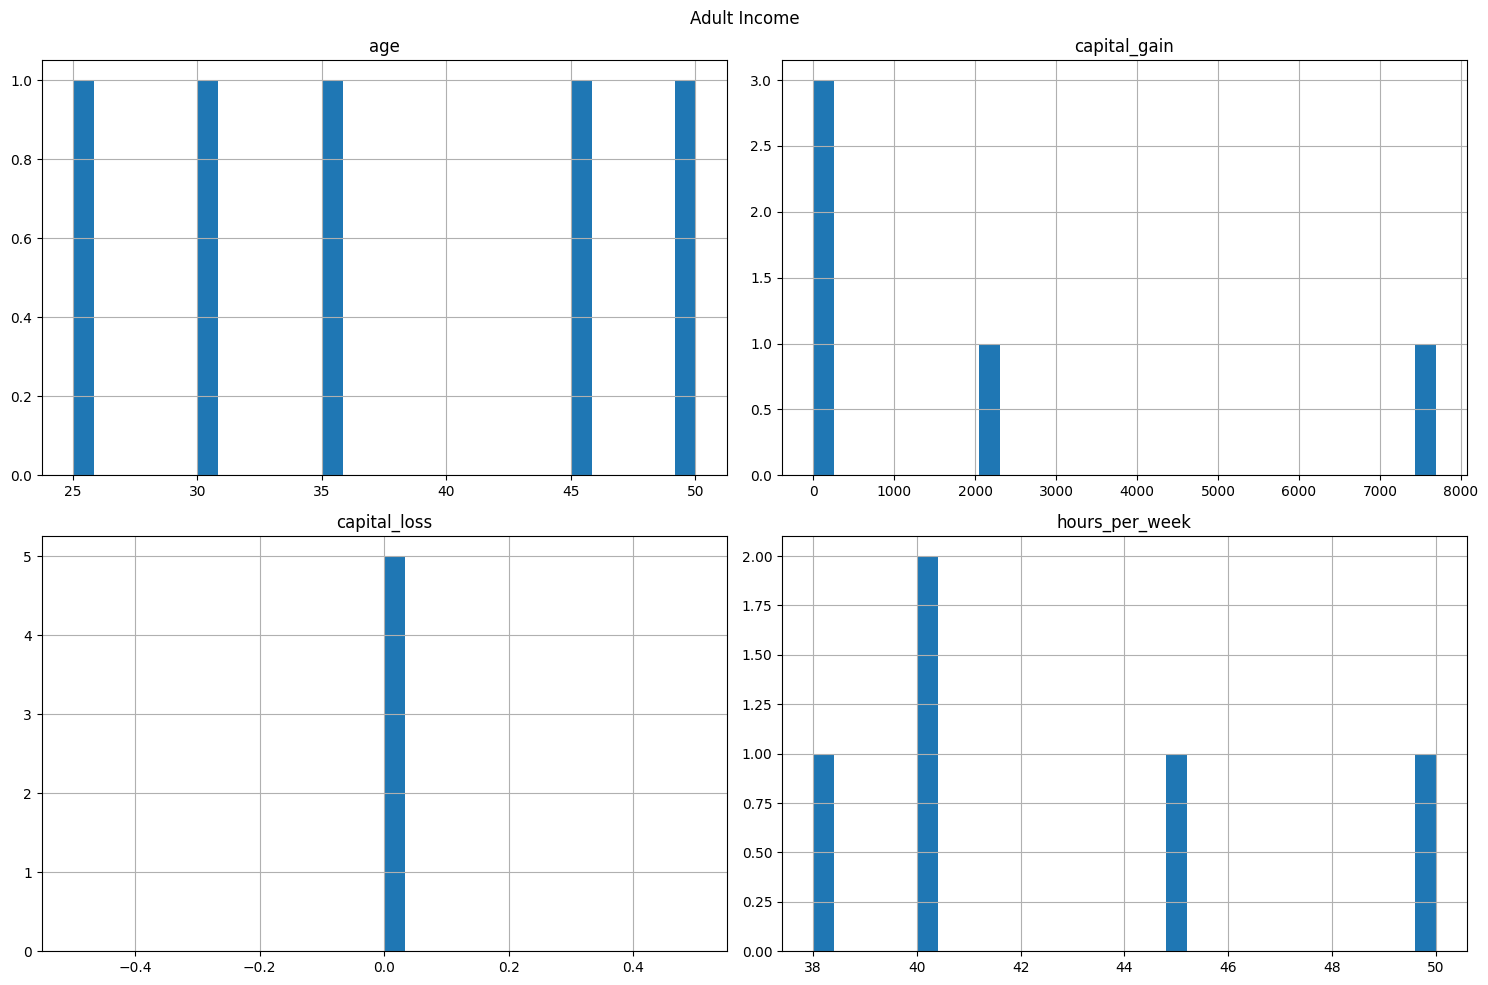

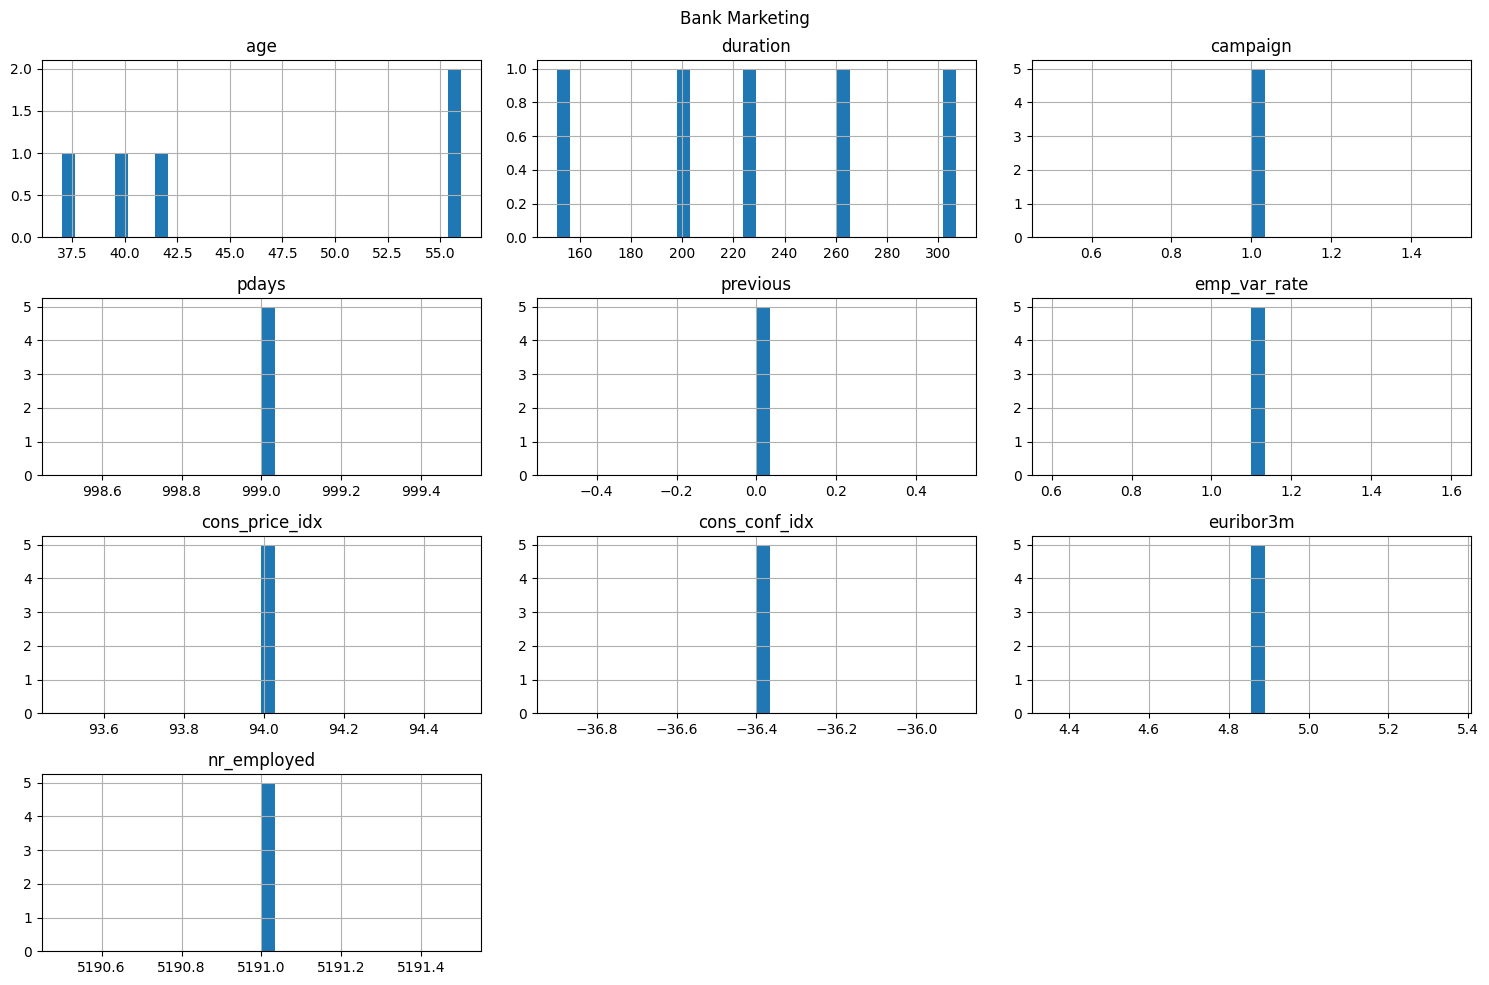

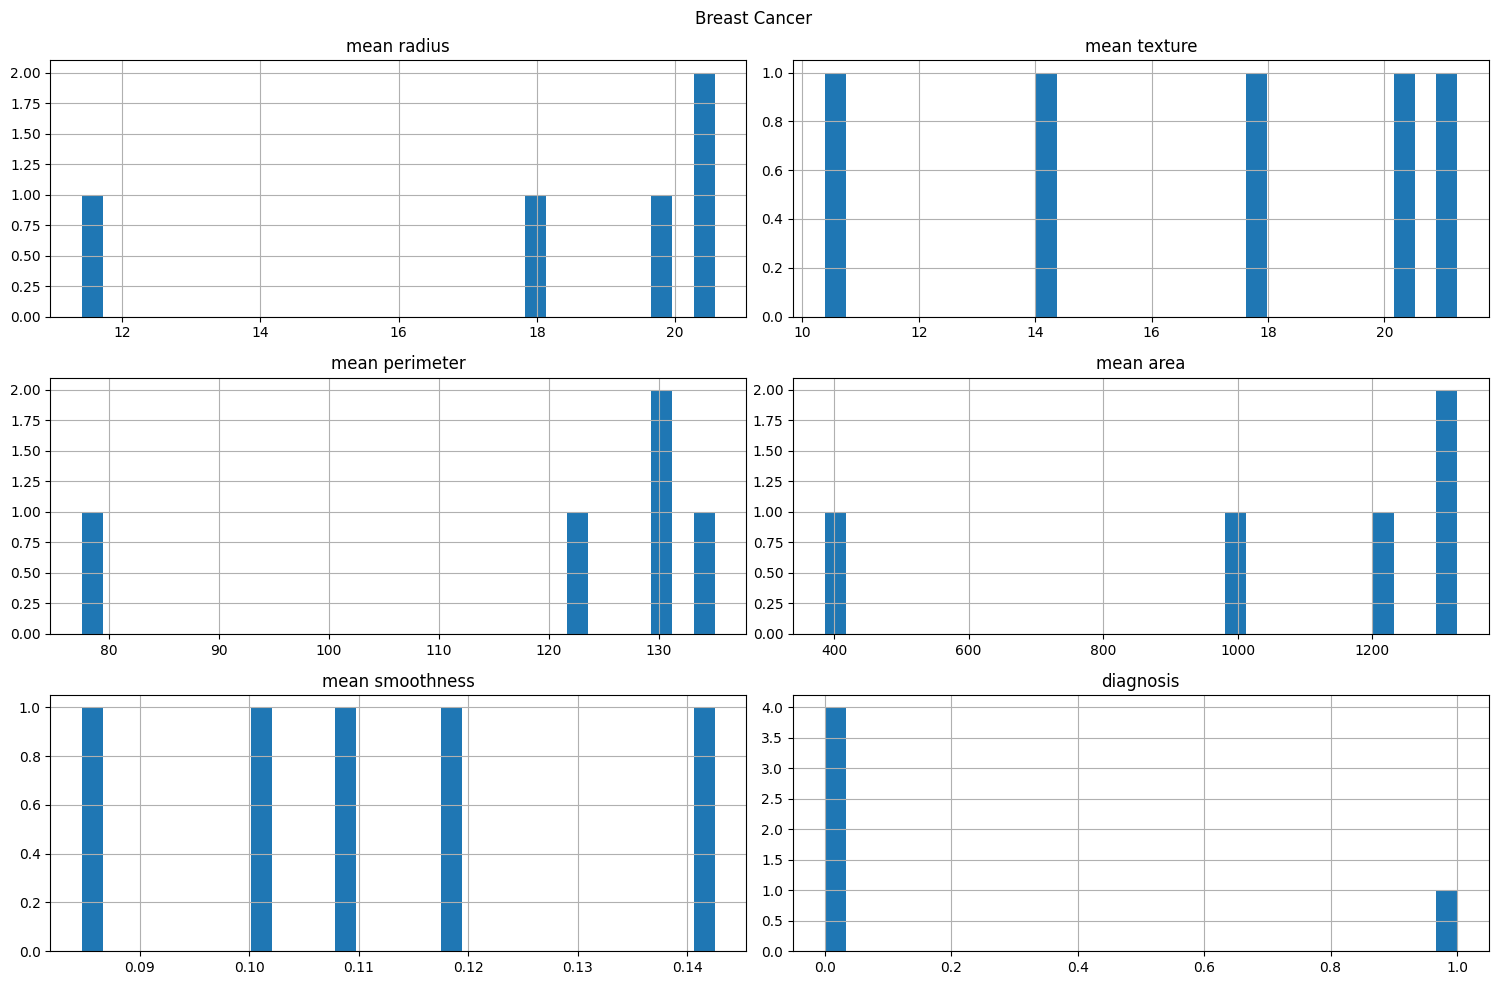

In [21]:
# ============================================================
# Distribution Analysis
# ============================================================

for name,df in datasets.items():

    numeric=df.select_dtypes(include=["int64","float64"])

    numeric.hist(

        figsize=(15,10),

        bins=30

    )

    plt.suptitle(name)

    plt.tight_layout()

    plt.show()

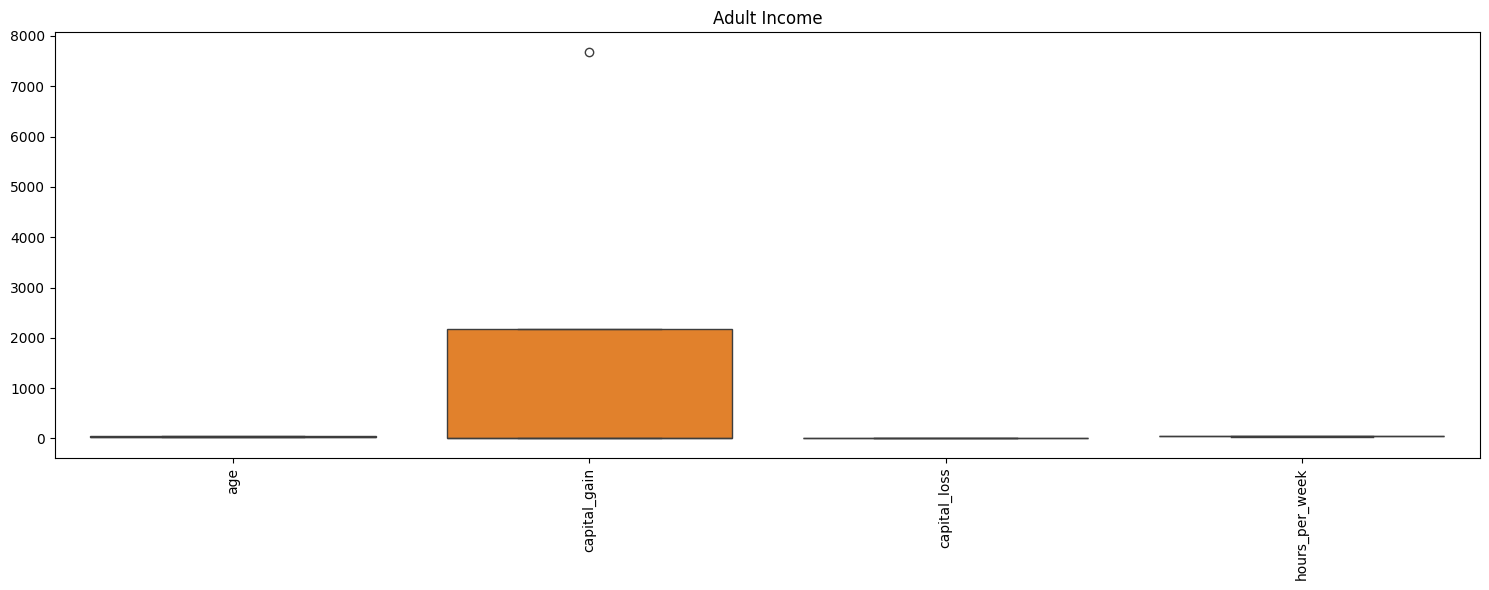

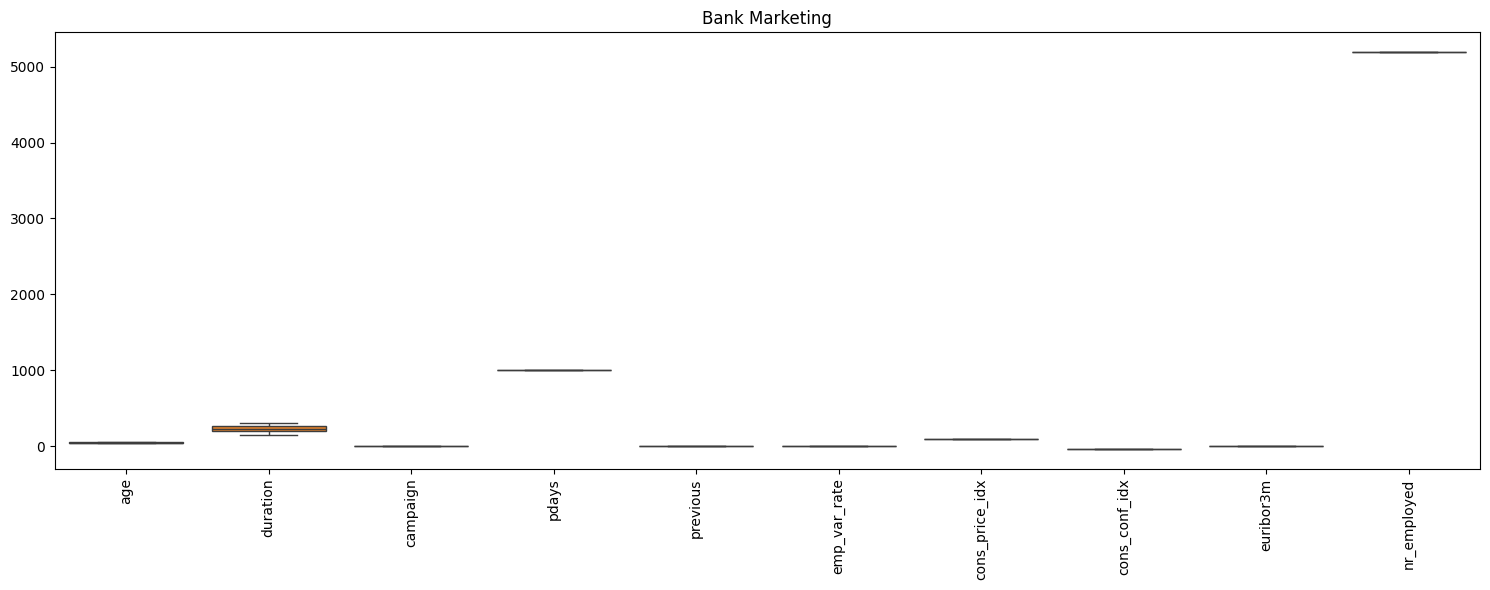

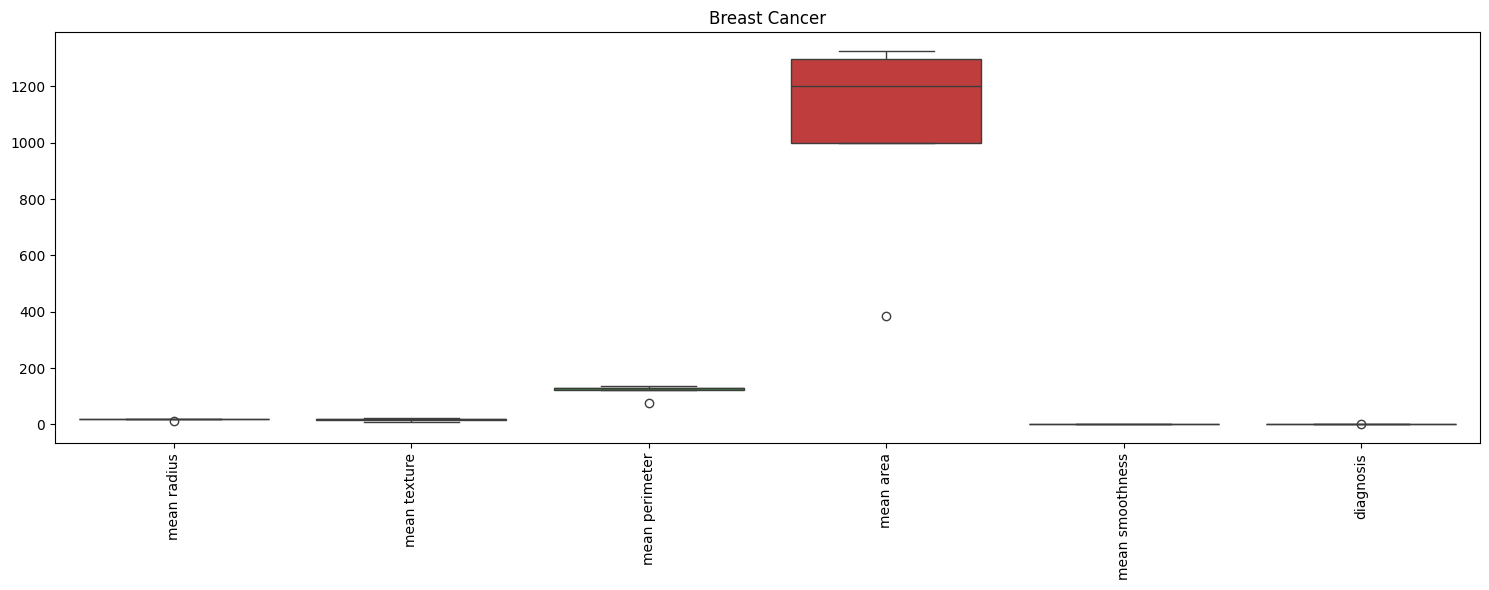

In [22]:
# ============================================================
# Boxplots
# ============================================================

for name,df in datasets.items():

    numeric=df.select_dtypes(include=["int64","float64"])

    plt.figure(figsize=(15,6))

    sns.boxplot(data=numeric)

    plt.title(name)

    plt.xticks(rotation=90)

    plt.tight_layout()

    plt.show()

In [23]:
# ============================================================
# Correlation Matrix
# ============================================================

correlations={}

for name,df in datasets.items():

    corr=df.select_dtypes(

        include=["int64","float64"]

    ).corr()

    correlations[name]=corr

    display(corr.round(3))

,age,capital_gain,capital_loss,hours_per_week
age,1.000,0.613,NaN,0.465
capital_gain,0.613,1.000,NaN,-0.394
capital_loss,NaN,NaN,NaN,NaN
hours_per_week,0.465,-0.394,NaN,1.000


,age,duration,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed
age,1.000,0.089,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,0.089,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
campaign,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pdays,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
previous,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
emp_var_rate,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cons_price_idx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cons_conf_idx,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
euribor3m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
nr_employed,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,diagnosis
mean radius,1.000,-0.279,0.993,0.998,-0.920,-0.965
mean texture,-0.279,1.000,-0.355,-0.246,0.155,0.442
mean perimeter,0.993,-0.355,1.000,0.985,-0.872,-0.982
mean area,0.998,-0.246,0.985,1.000,-0.938,-0.945
mean smoothness,-0.920,0.155,-0.872,-0.938,1.000,0.815
diagnosis,-0.965,0.442,-0.982,-0.945,0.815,1.000


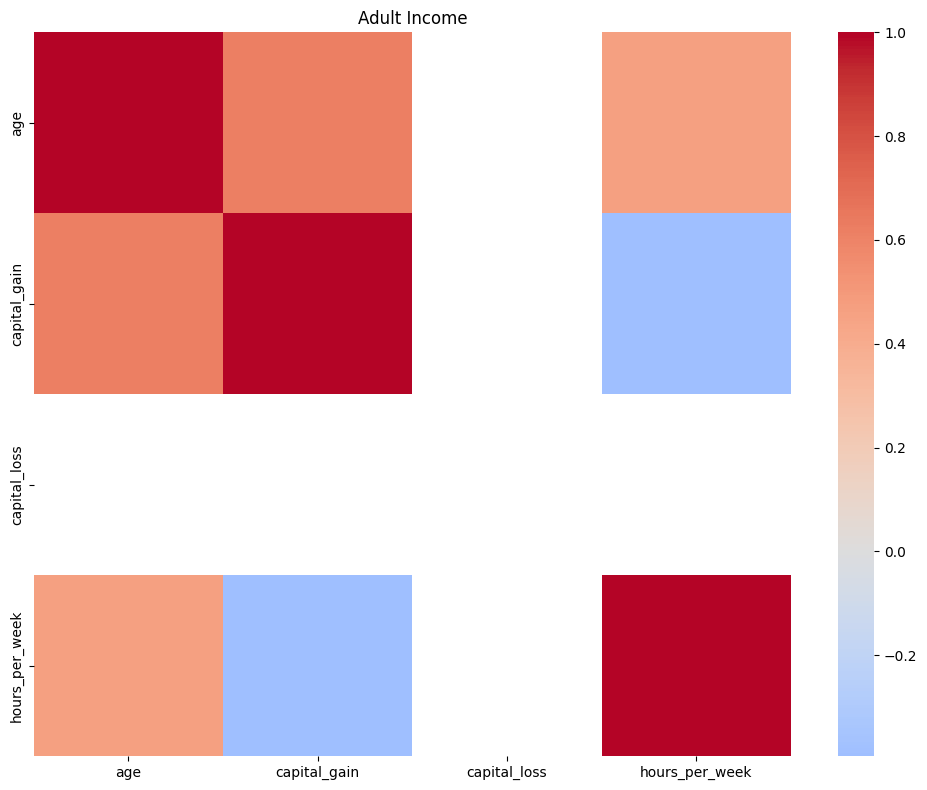

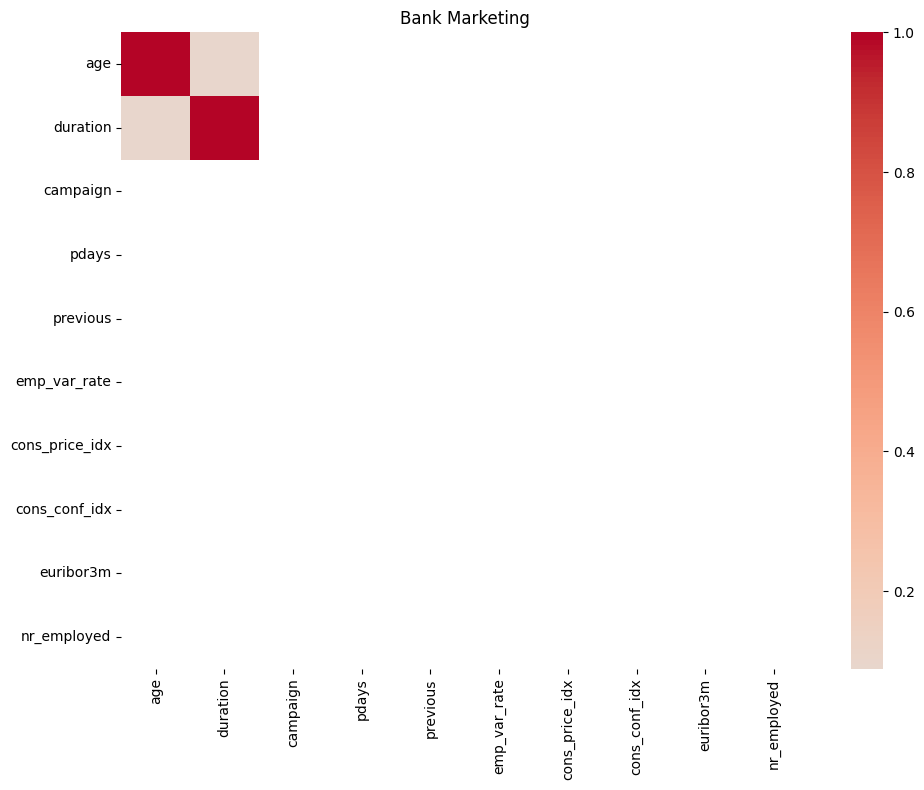

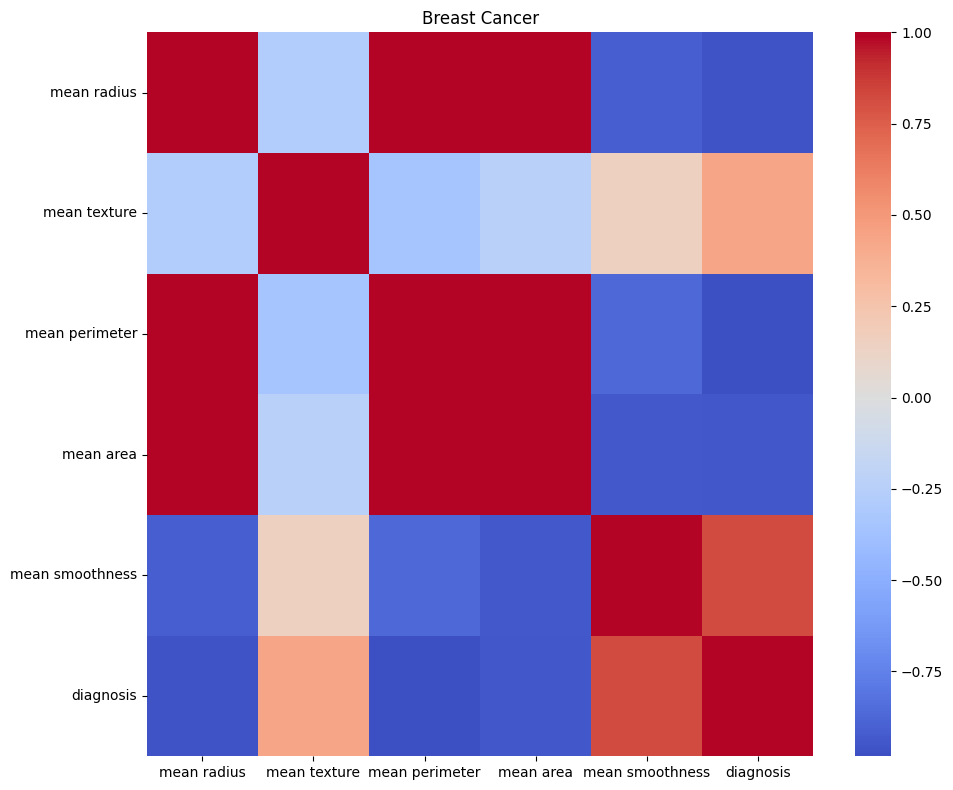

In [24]:
# ============================================================
# Heatmaps
# ============================================================

for name,corr in correlations.items():

    plt.figure(figsize=(10,8))

    sns.heatmap(

        corr,

        cmap="coolwarm",

        center=0

    )

    plt.title(name)

    plt.tight_layout()

    plt.show()

In [25]:
# ============================================================
# Save Reports
# ============================================================

REPORT=os.path.join(

    RESULT_PATH,

    "exploratory"

)

os.makedirs(REPORT,exist_ok=True)

missing_report.to_csv(

    os.path.join(

        REPORT,

        "missing_report.csv"

    ),

    index=False

)

numerical_summary.to_csv(

    os.path.join(

        REPORT,

        "numerical_summary.csv"

    ),

    index=False

)

shape_report.to_csv(

    os.path.join(

        REPORT,

        "distribution_statistics.csv"

    ),

    index=False

)

normality.to_csv(

    os.path.join(

        REPORT,

        "normality_test.csv"

    ),

    index=False

)

print("Reports Saved")

Reports Saved


In [26]:
# ============================================================
# Save Correlation Matrices
# ============================================================

for name,corr in correlations.items():

    corr.to_csv(

        os.path.join(

            REPORT,

            name.lower().replace(" ","_")

            +"_correlation.csv"

        )

    )

print("Correlation Matrices Saved")

Correlation Matrices Saved


In [27]:
# ============================================================
# Statistical Summary
# ============================================================

summary=[]

for name,df in datasets.items():

    summary.append({

        "Dataset":name,

        "Rows":df.shape[0],

        "Columns":df.shape[1],

        "Numeric":

        len(df.select_dtypes(

            include=["int64","float64"]

        ).columns),

        "Categorical":

        len(df.select_dtypes(

            include=["object"]

        ).columns)

    })

summary=pd.DataFrame(summary)

display(summary)

,Dataset,Rows,Columns,Numeric,Categorical
0,Adult Income,5,13,4,9
1,Bank Marketing,5,21,10,11
2,Breast Cancer,5,6,6,0


In [28]:
# ============================================================
# Verification
# ============================================================

print("="*70)

print("Exploratory Statistical Analysis Completed")

print("="*70)

print()

print("Completed")

print("✓ Descriptive Statistics")

print("✓ Distribution Analysis")

print("✓ Normality Testing")

print("✓ Skewness")

print("✓ Kurtosis")

print("✓ Correlation Analysis")

print("✓ Heatmaps")

print("✓ Statistical Reports")

print()

print("Ready for Gaussian Multivariate Model")

Exploratory Statistical Analysis Completed

Completed
✓ Descriptive Statistics
✓ Distribution Analysis
✓ Normality Testing
✓ Skewness
✓ Kurtosis
✓ Correlation Analysis
✓ Heatmaps
✓ Statistical Reports

Ready for Gaussian Multivariate Model


In [29]:
# ============================================================
# Gaussian Multivariate Model
# ============================================================

from sdv.single_table import GaussianCopulaSynthesizer

print("Gaussian Statistical Model Ready")

Gaussian Statistical Model Ready


In [30]:
# ============================================================
# Configuration
# ============================================================

MODEL_CONFIG = {

    "enforce_min_max_values": True,
    "enforce_rounding": True,
    "default_distribution": "norm"

}

print(MODEL_CONFIG)

{'enforce_min_max_values': True, 'enforce_rounding': True, 'default_distribution': 'norm'}


In [31]:
# ============================================================
# Initialize Models
# ============================================================

gaussian_models = {}

for name in datasets.keys():

    gaussian_models[name] = GaussianCopulaSynthesizer(

        metadata=metadata[name],

        enforce_min_max_values=MODEL_CONFIG["enforce_min_max_values"],

        enforce_rounding=MODEL_CONFIG["enforce_rounding"],

        default_distribution=MODEL_CONFIG["default_distribution"]

    )

print("Gaussian Models Initialized")

Gaussian Models Initialized


In [32]:
# ============================================================
# Train Gaussian Models
# ============================================================

for name, df in datasets.items():

    print(f"Training: {name}")

    gaussian_models[name].fit(df)

print("\nTraining Completed")

Training: Adult Income
Training: Bank Marketing
Training: Breast Cancer

Training Completed


In [33]:
# ============================================================
# Model Information
# ============================================================

summary=[]

for name, df in datasets.items():

    summary.append({

        "Dataset": name,

        "Rows": len(df),

        "Columns": df.shape[1],

        "Model": "Gaussian Multivariate"

    })

summary = pd.DataFrame(summary)

display(summary)

,Dataset,Rows,Columns,Model
0,Adult Income,5,13,Gaussian Multivariate
1,Bank Marketing,5,21,Gaussian Multivariate
2,Breast Cancer,5,6,Gaussian Multivariate


In [34]:
# ============================================================
# Save Models
# ============================================================

GAUSSIAN_MODEL_PATH = os.path.join(

    MODEL_PATH,

    "gaussian"

)

os.makedirs(

    GAUSSIAN_MODEL_PATH,

    exist_ok=True

)

for name, model in gaussian_models.items():

    filename = (

        name.lower()

        .replace(" ","_")

        + "_gaussian.pkl"

    )

    joblib.dump(

        model,

        os.path.join(

            GAUSSIAN_MODEL_PATH,

            filename

        )

    )

print("Models Saved")

Models Saved


In [35]:
# ============================================================
# Verify Saved Models
# ============================================================

for name in datasets.keys():

    filename = (

        name.lower()

        .replace(" ","_")

        + "_gaussian.pkl"

    )

    model = joblib.load(

        os.path.join(

            GAUSSIAN_MODEL_PATH,

            filename

        )

    )

    print(f"{name} ✓")

Adult Income ✓
Bank Marketing ✓
Breast Cancer ✓


In [36]:
# ============================================================
# Save Report
# ============================================================

summary.to_csv(

    os.path.join(

        RESULT_PATH,

        "gaussian_model_summary.csv"

    ),

    index=False

)

print("Model Summary Saved")

Model Summary Saved


In [37]:
# ============================================================
# Verification
# ============================================================

print("="*70)

print("Gaussian Multivariate Models Completed")

print("="*70)

print()

for dataset in datasets.keys():

    print(f"✓ {dataset}")

print()

print("Models Stored In")

print(GAUSSIAN_MODEL_PATH)

print()

print("Ready For")

print("✓ Synthetic Data Generation")

print("✓ Statistical Evaluation")

print("✓ Comparison with GAN Models")

Gaussian Multivariate Models Completed

✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer

Models Stored In
/content/SPP_GAN_Project/models/statistical/gaussian

Ready For
✓ Synthetic Data Generation
✓ Statistical Evaluation
✓ Comparison with GAN Models


In [38]:
# ============================================================
# Gaussian Synthetic Data Generation
# ============================================================

N_SAMPLES = {

    "Adult Income": len(datasets["Adult Income"]),

    "Bank Marketing": len(datasets["Bank Marketing"]),

    "Breast Cancer": len(datasets["Breast Cancer"])

}

GAUSSIAN_DATA_PATH = os.path.join(

    PROJECT,

    "synthetic_data",

    "gaussian"

)

os.makedirs(

    GAUSSIAN_DATA_PATH,

    exist_ok=True

)

print("Synthetic data directory created.")

Synthetic data directory created.


In [39]:
# ============================================================
# Generate Synthetic Datasets
# ============================================================

gaussian_synthetic = {}

for name, model in gaussian_models.items():

    print(f"Generating {name}...")

    synthetic = model.sample(

        num_rows=N_SAMPLES[name]

    )

    gaussian_synthetic[name] = synthetic

print("\nSynthetic datasets generated successfully.")

Generating Adult Income...
Generating Bank Marketing...
Generating Breast Cancer...

Synthetic datasets generated successfully.


In [40]:
# ============================================================
# Verify Synthetic Datasets
# ============================================================

verification = []

for name in datasets.keys():

    real = datasets[name]

    synth = gaussian_synthetic[name]

    verification.append({

        "Dataset": name,

        "Real Rows": real.shape[0],

        "Synthetic Rows": synth.shape[0],

        "Columns": synth.shape[1],

        "Missing Values":

        synth.isnull().sum().sum(),

        "Duplicates":

        synth.duplicated().sum()

    })

verification = pd.DataFrame(verification)

display(verification)

,Dataset,Real Rows,Synthetic Rows,Columns,Missing Values,Duplicates
0,Adult Income,5,5,13,0,0
1,Bank Marketing,5,5,21,0,0
2,Breast Cancer,5,5,6,0,0


In [41]:
# ============================================================
# Preview Synthetic Data
# ============================================================

for name, df in gaussian_synthetic.items():

    print("="*70)

    print(name)

    print("="*70)

    display(df.head())

Adult Income


,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,38,Private,Bachelors,Married-civ-spouse,Exec-managerial,Own-child,Black,Male,5195,0,38,China,<=50K
1,36,Self-emp-not-inc,Bachelors,Married-civ-spouse,Craft-repair,Not-in-family,White,Male,3132,0,41,United-States,<=50K
2,27,Federal-gov,Some-college,Never-married,Adm-clerical,Not-in-family,White,Female,543,0,40,United-States,<=50K
3,38,Self-emp-not-inc,HS-grad,Never-married,Craft-repair,Wife,Black,Male,4511,0,38,United-States,>50K
4,43,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Not-in-family,Black,Female,1872,0,47,United-States,>50K


Bank Marketing


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,49,services,married,high.school,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,37,technician,married,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,admin.,married,basic.9y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,50,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,37,technician,married,professional.course,no,yes,no,cellular,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Breast Cancer


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,diagnosis
0,20.57,12.73,135.10,1326.0,0.10082,0
1,17.54,15.23,115.93,998.4,0.10937,0
2,20.57,16.19,135.10,1326.0,0.09067,0
3,19.20,18.37,125.08,1184.1,0.09983,0
4,20.57,12.56,135.10,1326.0,0.08474,0


In [42]:
# ============================================================
# Save Synthetic Data
# ============================================================

for name, df in gaussian_synthetic.items():

    filename = (

        name.lower()

        .replace(" ","_")

        + "_gaussian.csv"

    )

    df.to_csv(

        os.path.join(

            GAUSSIAN_DATA_PATH,

            filename

        ),

        index=False

    )

print("Synthetic datasets saved.")

Synthetic datasets saved.


In [43]:
# ============================================================
# Synthetic Dataset Summary
# ============================================================

summary = []

for name, df in gaussian_synthetic.items():

    summary.append({

        "Dataset": name,

        "Rows": df.shape[0],

        "Columns": df.shape[1],

        "Memory (MB)": round(

            df.memory_usage(deep=True).sum()

            /1024**2,

            2

        )

    })

summary = pd.DataFrame(summary)

display(summary)

,Dataset,Rows,Columns,Memory (MB)
0,Adult Income,5,13,0.0
1,Bank Marketing,5,21,0.0
2,Breast Cancer,5,6,0.0


In [44]:
# ============================================================
# Save Reports
# ============================================================

summary.to_csv(

    os.path.join(

        RESULT_PATH,

        "gaussian_synthetic_summary.csv"

    ),

    index=False

)

verification.to_csv(

    os.path.join(

        RESULT_PATH,

        "gaussian_generation_report.csv"

    ),

    index=False

)

print("Reports saved.")

Reports saved.


In [46]:
# ============================================================
# Verification
# ============================================================

print("="*70)

print("Gaussian Synthetic Data Generation Completed")

print("="*70)

print()

for name in gaussian_synthetic.keys():

    print(f"✓ {name}")

print()

print("Saved Location:")

print(GAUSSIAN_DATA_PATH)

print()

print("Ready For:")

print("✓ Statistical Evaluation")

print("✓ Utility Evaluation")

print("✓ Privacy Evaluation")

print("✓ Comparison with Copula and GAN Models")

Gaussian Synthetic Data Generation Completed

✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer

Saved Location:
/content/SPP_GAN_Project/synthetic_data/gaussian

Ready For:
✓ Statistical Evaluation
✓ Utility Evaluation
✓ Privacy Evaluation
✓ Comparison with Copula and GAN Models


In [55]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip -q install sdv==1.12.0
!pip -q install sdmetrics
!pip -q install copulas
!pip -q install scipy
!pip -q install joblib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.2

In [56]:
# ============================================================
# Import Libraries
# ============================================================

import os
import random
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [57]:
# ============================================================
# Project Configuration
# ============================================================

PROJECT = "/content/SPP_GAN_Project"

DATA_PATH = os.path.join(
    PROJECT,
    "datasets",
    "processed"
)

MODEL_PATH = os.path.join(
    PROJECT,
    "models",
    "gaussian_copula"
)

SYNTHETIC_PATH = os.path.join(
    PROJECT,
    "synthetic_data",
    "gaussian_copula"
)

RESULT_PATH = os.path.join(
    PROJECT,
    "results",
    "gaussian_copula"
)

for path in [

    MODEL_PATH,

    SYNTHETIC_PATH,

    RESULT_PATH

]:

    os.makedirs(

        path,

        exist_ok=True

    )

print("Project Initialized")

Project Initialized


In [58]:
# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

print(f"Random Seed = {SEED}")

Random Seed = 42


In [59]:
# ============================================================
# Load Processed Datasets
# ============================================================

datasets = {

    "Adult Income": pd.read_csv(

        os.path.join(

            DATA_PATH,

            "adult_income_processed.csv"

        )

    ),

    "Bank Marketing": pd.read_csv(

        os.path.join(

            DATA_PATH,

            "bank_marketing_processed.csv"

        )

    ),

    "Breast Cancer": pd.read_csv(

        os.path.join(

            DATA_PATH,

            "breast_cancer_processed.csv"

        )

    )

}

print("Datasets Loaded Successfully")

Datasets Loaded Successfully


In [60]:
# ============================================================
# Dataset Verification
# ============================================================

summary=[]

for name,df in datasets.items():

    summary.append({

        "Dataset":name,

        "Rows":df.shape[0],

        "Columns":df.shape[1],

        "Missing":df.isnull().sum().sum(),

        "Duplicates":df.duplicated().sum()

    })

summary=pd.DataFrame(summary)

display(summary)

,Dataset,Rows,Columns,Missing,Duplicates
0,Adult Income,5,13,0,0
1,Bank Marketing,5,21,0,0
2,Breast Cancer,5,6,0,0


In [61]:
# ============================================================
# Metadata Detection
# ============================================================

metadata = {}

for name,df in datasets.items():

    meta = SingleTableMetadata()

    meta.detect_from_dataframe(df)

    metadata[name]=meta

print("Metadata Generated Successfully")

Metadata Generated Successfully


In [62]:
# ============================================================
# Metadata Summary
# ============================================================

for name,meta in metadata.items():

    print("="*70)

    print(name)

    print("="*70)

    display(meta.to_dict())

Adult Income


{'columns': {'age': {'sdtype': 'numerical'},
  'workclass': {'sdtype': 'categorical'},
  'education': {'sdtype': 'categorical'},
  'marital_status': {'sdtype': 'categorical'},
  'occupation': {'sdtype': 'categorical'},
  'relationship': {'sdtype': 'categorical'},
  'race': {'sdtype': 'categorical'},
  'sex': {'sdtype': 'categorical'},
  'capital_gain': {'sdtype': 'numerical'},
  'capital_loss': {'sdtype': 'numerical'},
  'hours_per_week': {'sdtype': 'numerical'},
  'native_country': {'sdtype': 'categorical'},
  'income': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

Bank Marketing


{'columns': {'age': {'sdtype': 'numerical'},
  'job': {'sdtype': 'categorical'},
  'marital': {'sdtype': 'categorical'},
  'education': {'sdtype': 'categorical'},
  'default': {'sdtype': 'categorical'},
  'housing': {'sdtype': 'categorical'},
  'loan': {'sdtype': 'categorical'},
  'contact': {'sdtype': 'categorical'},
  'month': {'sdtype': 'categorical'},
  'day_of_week': {'sdtype': 'categorical'},
  'duration': {'sdtype': 'numerical'},
  'campaign': {'sdtype': 'numerical'},
  'pdays': {'sdtype': 'numerical'},
  'previous': {'sdtype': 'numerical'},
  'poutcome': {'sdtype': 'categorical'},
  'emp_var_rate': {'sdtype': 'numerical'},
  'cons_price_idx': {'sdtype': 'numerical'},
  'cons_conf_idx': {'sdtype': 'numerical'},
  'euribor3m': {'sdtype': 'numerical'},
  'nr_employed': {'sdtype': 'numerical'},
  'y': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

Breast Cancer


{'columns': {'mean radius': {'sdtype': 'numerical'},
  'mean texture': {'sdtype': 'numerical'},
  'mean perimeter': {'sdtype': 'numerical'},
  'mean area': {'sdtype': 'numerical'},
  'mean smoothness': {'sdtype': 'numerical'},
  'diagnosis': {'sdtype': 'numerical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1'}

In [63]:
# ============================================================
# Feature Summary
# ============================================================

feature_summary=[]

for name,df in datasets.items():

    feature_summary.append({

        "Dataset":name,

        "Features":df.shape[1],

        "Numerical":

        len(

            df.select_dtypes(

                include=["int64","float64"]

            ).columns

        ),

        "Categorical":

        len(

            df.select_dtypes(

                include=["object","category"]

            ).columns

        )

    })

feature_summary=pd.DataFrame(feature_summary)

display(feature_summary)

,Dataset,Features,Numerical,Categorical
0,Adult Income,13,4,9
1,Bank Marketing,21,10,11
2,Breast Cancer,6,6,0


In [64]:
# ============================================================
# Save Metadata
# ============================================================

for name,meta in metadata.items():

    filename=name.lower().replace(" ","_")

    meta.save_to_json(

        os.path.join(

            MODEL_PATH,

            filename+"_metadata.json"

        )

    )

print("Metadata Saved")

Metadata Saved


In [65]:
# ============================================================
# Dataset Overview
# ============================================================

for name,df in datasets.items():

    print("="*70)

    print(name)

    print("="*70)

    display(df.head())

    display(df.describe(include="all"))

Adult Income


,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,30,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,2174,0,40,United-States,<=50K
1,45,Self-emp-not-inc,HS-grad,Divorced,Craft-repair,Not-in-family,Black,Female,0,0,50,United-States,>50K
2,25,Private,Some-college,Never-married,Adm-clerical,Own-child,White,Female,0,0,38,United-States,<=50K
3,50,Federal-gov,Bachelors,Married-civ-spouse,Exec-managerial,Wife,Asian-Pac-Islander,Male,7688,0,40,China,>50K
4,35,Local-gov,Masters,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,45,United-States,<=50K


,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
count,5.000000,5,5,5,5,5,5,5,5.000000,5.0,5.000000,5,5
unique,NaN,4,4,3,4,4,3,2,NaN,NaN,NaN,2,2
top,NaN,Private,Bachelors,Married-civ-spouse,Exec-managerial,Not-in-family,White,Female,NaN,NaN,NaN,United-States,<=50K
freq,NaN,2,2,2,2,2,3,3,NaN,NaN,NaN,4,3
mean,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1972.400000,0.0,42.600000,NaN,NaN
std,10.368221,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3330.908705,0.0,4.878524,NaN,NaN
min,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,38.000000,NaN,NaN
25%,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,40.000000,NaN,NaN
50%,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0,40.000000,NaN,NaN
75%,45.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2174.000000,0.0,45.000000,NaN,NaN


Bank Marketing


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,40,admin.,married,basic.9y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,42,technician,married,professional.course,no,yes,no,cellular,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,yes,yes,cellular,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,5.000000,5,5,5,5,5,5,5,5,5,...,5.0,5.0,5.0,5,5.0,5.000,5.0,5.000,5.0,5
unique,NaN,4,1,4,1,2,2,2,1,1,...,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,1
top,NaN,services,married,high.school,no,yes,no,telephone,may,mon,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,2,5,2,5,4,4,3,5,5,...,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,5
mean,46.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN
std,9.121403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,NaN,0.0,0.000,0.0,0.000,0.0,NaN
min,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN
25%,40.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN
50%,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN
75%,56.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,999.0,0.0,NaN,1.1,93.994,-36.4,4.857,5191.0,NaN


Breast Cancer


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,131.20,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,1
4,20.29,14.34,135.10,1297.0,0.10030,0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,diagnosis
count,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000
mean,17.992000,16.824000,119.33600,1042.620000,0.111108,0.200000
std,3.807929,4.495134,23.76206,388.421771,0.021523,0.447214
min,11.420000,10.380000,77.58000,386.100000,0.084740,0.000000
25%,17.990000,14.340000,122.80000,1001.000000,0.100300,0.000000
50%,19.690000,17.770000,130.00000,1203.000000,0.109600,0.000000
75%,20.290000,20.380000,131.20000,1297.000000,0.118400,0.000000
max,20.570000,21.250000,135.10000,1326.000000,0.142500,1.000000


In [66]:
# ============================================================
# Memory Usage
# ============================================================

memory=[]

for name,df in datasets.items():

    memory.append({

        "Dataset":name,

        "Memory(MB)":round(

            df.memory_usage(deep=True).sum()/1024**2,

            2

        )

    })

memory=pd.DataFrame(memory)

display(memory)

,Dataset,Memory(MB)
0,Adult Income,0.0
1,Bank Marketing,0.0
2,Breast Cancer,0.0


In [67]:
# ============================================================
# Save Reports
# ============================================================

summary.to_csv(

    os.path.join(

        RESULT_PATH,

        "dataset_summary.csv"

    ),

    index=False

)

feature_summary.to_csv(

    os.path.join(

        RESULT_PATH,

        "feature_summary.csv"

    ),

    index=False

)

memory.to_csv(

    os.path.join(

        RESULT_PATH,

        "memory_report.csv"

    ),

    index=False

)

print("Reports Saved")

Reports Saved


In [68]:
# ============================================================
# Verification
# ============================================================

print("="*70)

print("Gaussian Copula Initialization Completed")

print("="*70)

print()

print("Datasets")

for name in datasets.keys():

    print("✓",name)

print()

print("Metadata Generated")

print("Project Directories Created")

print("Reports Saved")

print()

print("Ready For")

print("✓ Gaussian Copula Model Training")

Gaussian Copula Initialization Completed

Datasets
✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer

Metadata Generated
Project Directories Created
Reports Saved

Ready For
✓ Gaussian Copula Model Training


In [69]:
# ============================================================
# Gaussian Copula Synthesizer
# ============================================================

from sdv.single_table import GaussianCopulaSynthesizer

print("Gaussian Copula Synthesizer Ready")

Gaussian Copula Synthesizer Ready


In [70]:
# ============================================================
# Model Configuration
# ============================================================

GC_CONFIG = {

    "enforce_min_max_values": True,

    "enforce_rounding": True,

    "default_distribution": "beta",

    "numerical_distributions": None

}

print(GC_CONFIG)

{'enforce_min_max_values': True, 'enforce_rounding': True, 'default_distribution': 'beta', 'numerical_distributions': None}


In [71]:
# ============================================================
# Initialize Gaussian Copula Models
# ============================================================

gc_models = {}

for name, meta in metadata.items():

    gc_models[name] = GaussianCopulaSynthesizer(

        metadata=meta,

        enforce_min_max_values=GC_CONFIG["enforce_min_max_values"],

        enforce_rounding=GC_CONFIG["enforce_rounding"],

        default_distribution=GC_CONFIG["default_distribution"],

        numerical_distributions=GC_CONFIG["numerical_distributions"]

    )

print("All Gaussian Copula Models Initialized")

All Gaussian Copula Models Initialized


In [72]:
# ============================================================
# Train Models
# ============================================================

training_summary = []

for name, df in datasets.items():

    print(f"\nTraining {name}...")

    model = gc_models[name]

    model.fit(df)

    training_summary.append({

        "Dataset": name,

        "Rows": df.shape[0],

        "Columns": df.shape[1],

        "Status": "Completed"

    })

print("\nAll Models Trained Successfully")


Training Adult Income...

Training Bank Marketing...

Training Breast Cancer...

All Models Trained Successfully


In [73]:
# ============================================================
# Training Summary
# ============================================================

training_summary = pd.DataFrame(training_summary)

display(training_summary)

,Dataset,Rows,Columns,Status
0,Adult Income,5,13,Completed
1,Bank Marketing,5,21,Completed
2,Breast Cancer,5,6,Completed


In [74]:
# ============================================================
# Save Models
# ============================================================

for name, model in gc_models.items():

    filename = (

        name.lower()

        .replace(" ", "_")

        + "_gaussian_copula.pkl"

    )

    joblib.dump(

        model,

        os.path.join(

            MODEL_PATH,

            filename

        )

    )

print("Models Saved Successfully")

Models Saved Successfully


In [75]:
# ============================================================
# Verify Saved Models
# ============================================================

loaded_models = {}

for name in datasets.keys():

    filename = (

        name.lower()

        .replace(" ", "_")

        + "_gaussian_copula.pkl"

    )

    loaded_models[name] = joblib.load(

        os.path.join(

            MODEL_PATH,

            filename

        )

    )

    print(f"✓ {name}")

✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer


In [76]:
# ============================================================
# Save Training Report
# ============================================================

training_summary.to_csv(

    os.path.join(

        RESULT_PATH,

        "gaussian_copula_training_summary.csv"

    ),

    index=False

)

print("Training Report Saved")

Training Report Saved


In [77]:
# ============================================================
# Model Information
# ============================================================

model_info = pd.DataFrame({

    "Dataset": list(datasets.keys()),

    "Model": "Gaussian Copula",

    "Distribution": GC_CONFIG["default_distribution"],

    "Min-Max Constraint": GC_CONFIG["enforce_min_max_values"],

    "Rounding": GC_CONFIG["enforce_rounding"]

})

display(model_info)

,Dataset,Model,Distribution,Min-Max Constraint,Rounding
0,Adult Income,Gaussian Copula,beta,True,True
1,Bank Marketing,Gaussian Copula,beta,True,True
2,Breast Cancer,Gaussian Copula,beta,True,True


In [78]:
# ============================================================
# Final Verification
# ============================================================

print("=" * 70)
print("Gaussian Copula Training Completed")
print("=" * 70)

print("\nDatasets:")

for dataset in datasets.keys():

    print(f"✓ {dataset}")

print("\nSaved Models:")
print(MODEL_PATH)

print("\nReports:")
print("✓ gaussian_copula_training_summary.csv")

print("\nNext Step:")
print("✓ Generate Synthetic Data")
print("✓ Statistical Evaluation")

Gaussian Copula Training Completed

Datasets:
✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer

Saved Models:
/content/SPP_GAN_Project/models/gaussian_copula

Reports:
✓ gaussian_copula_training_summary.csv

Next Step:
✓ Generate Synthetic Data
✓ Statistical Evaluation


In [79]:
# ============================================================
# Synthetic Data Generation Configuration
# ============================================================

N_SAMPLES = {

    name: len(df)

    for name, df in datasets.items()

}

synthetic_data = {}

print("Synthetic Sample Size")

display(pd.DataFrame({

    "Dataset": N_SAMPLES.keys(),

    "Samples": N_SAMPLES.values()

}))

Synthetic Sample Size


,Dataset,Samples
0,Adult Income,5
1,Bank Marketing,5
2,Breast Cancer,5


In [80]:
# ============================================================
# Generate Synthetic Data
# ============================================================

for name, model in gc_models.items():

    print(f"Generating Synthetic Data : {name}")

    synthetic = model.sample(

        num_rows=N_SAMPLES[name]

    )

    synthetic_data[name] = synthetic

print("\nSynthetic Data Generation Completed")

Generating Synthetic Data : Adult Income
Generating Synthetic Data : Bank Marketing
Generating Synthetic Data : Breast Cancer

Synthetic Data Generation Completed


In [81]:
# ============================================================
# Verification
# ============================================================

verification=[]

for name in datasets.keys():

    real=datasets[name]

    synth=synthetic_data[name]

    verification.append({

        "Dataset":name,

        "Real Rows":real.shape[0],

        "Synthetic Rows":synth.shape[0],

        "Columns":synth.shape[1],

        "Missing Values":int(synth.isnull().sum().sum()),

        "Duplicate Rows":int(synth.duplicated().sum())

    })

verification=pd.DataFrame(verification)

display(verification)

,Dataset,Real Rows,Synthetic Rows,Columns,Missing Values,Duplicate Rows
0,Adult Income,5,5,13,0,0
1,Bank Marketing,5,5,21,0,0
2,Breast Cancer,5,5,6,0,0


In [82]:
# ============================================================
# Preview
# ============================================================

for name,df in synthetic_data.items():

    print("="*70)

    print(name)

    print("="*70)

    display(df.head())

Adult Income


,age,workclass,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,29,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,2226,0,40,China,<=50K
1,32,Local-gov,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Female,347,0,41,United-States,<=50K
2,26,Local-gov,Bachelors,Never-married,Craft-repair,Husband,White,Female,0,0,42,United-States,<=50K
3,26,Private,Bachelors,Married-civ-spouse,Exec-managerial,Not-in-family,Black,Male,28,0,40,China,<=50K
4,47,Local-gov,Bachelors,Married-civ-spouse,Exec-managerial,Husband,Black,Male,3037,0,47,China,<=50K


Bank Marketing


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,39,services,married,basic.4y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,39,technician,married,basic.9y,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,39,admin.,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,39,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,39,technician,married,professional.course,no,yes,no,cellular,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Breast Cancer


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,diagnosis
0,20.57,13.55,135.10,1326.0,0.10763,0
1,20.55,15.73,133.92,1267.7,0.12085,0
2,20.57,18.90,135.10,1326.0,0.10101,0
3,20.57,20.40,135.06,1325.6,0.11286,0
4,20.57,16.05,135.10,1326.0,0.09988,0


In [83]:
# ============================================================
# Basic Statistical Comparison
# ============================================================

comparison=[]

for name in datasets.keys():

    real=datasets[name]

    synth=synthetic_data[name]

    numeric=real.select_dtypes(

        include=["int64","float64"]

    ).columns

    comparison.append({

        "Dataset":name,

        "Real Mean":

        round(real[numeric].mean().mean(),4),

        "Synthetic Mean":

        round(synth[numeric].mean().mean(),4),

        "Real Std":

        round(real[numeric].std().mean(),4),

        "Synthetic Std":

        round(synth[numeric].std().mean(),4)

    })

comparison=pd.DataFrame(comparison)

display(comparison)

,Dataset,Real Mean,Synthetic Mean,Real Std,Synthetic Std
0,Adult Income,513.0000,300.4000,836.5389,355.1900
1,Bank Marketing,652.9351,656.1951,6.8622,5.1984
2,Breast Cancer,199.5139,247.7861,70.1593,4.8813


In [84]:
# ============================================================
# Save Synthetic Datasets
# ============================================================

for name,df in synthetic_data.items():

    filename=(

        name.lower()

        .replace(" ","_")

        +"_gaussian_copula.csv"

    )

    df.to_csv(

        os.path.join(

            SYNTHETIC_PATH,

            filename

        ),

        index=False

    )

print("Synthetic Datasets Saved")

Synthetic Datasets Saved


In [85]:
# ============================================================
# Backup Models
# ============================================================

BACKUP_PATH=os.path.join(

    MODEL_PATH,

    "backup"

)

os.makedirs(

    BACKUP_PATH,

    exist_ok=True

)

for name,model in gc_models.items():

    filename=(

        name.lower()

        .replace(" ","_")

        +"_gaussian_copula.pkl"

    )

    joblib.dump(

        model,

        os.path.join(

            BACKUP_PATH,

            filename

        )

    )

print("Backup Completed")

Backup Completed


In [86]:
# ============================================================
# Save Reports
# ============================================================

verification.to_csv(

    os.path.join(

        RESULT_PATH,

        "generation_report.csv"

    ),

    index=False

)

comparison.to_csv(

    os.path.join(

        RESULT_PATH,

        "basic_statistics.csv"

    ),

    index=False

)

print("Reports Saved")

Reports Saved


In [87]:
# ============================================================
# Verify Saved Files
# ============================================================

for name in datasets.keys():

    file=os.path.join(

        SYNTHETIC_PATH,

        name.lower().replace(" ","_")

        +"_gaussian_copula.csv"

    )

    df=pd.read_csv(file)

    print(

        f"{name:20s}",

        df.shape

    )

Adult Income         (5, 13)
Bank Marketing       (5, 21)
Breast Cancer        (5, 6)


In [88]:
# ============================================================
# Summary
# ============================================================

summary=[]

for name,df in synthetic_data.items():

    summary.append({

        "Dataset":name,

        "Rows":df.shape[0],

        "Columns":df.shape[1],

        "Memory (MB)":round(

            df.memory_usage(

                deep=True

            ).sum()/1024**2,

            2

        )

    })

summary=pd.DataFrame(summary)

display(summary)

,Dataset,Rows,Columns,Memory (MB)
0,Adult Income,5,13,0.0
1,Bank Marketing,5,21,0.0
2,Breast Cancer,5,6,0.0


In [89]:
# ============================================================
# Final Verification
# ============================================================

print("="*70)

print("Gaussian Copula Module Completed")

print("="*70)

print()

print("Datasets Generated")

for dataset in synthetic_data.keys():

    print("✓",dataset)

print()

print("Models Saved")

print("✓ Gaussian Copula Models")

print()

print("Synthetic Data Saved")

print("✓ CSV Files")

print()

print("Reports Generated")

print("✓ generation_report.csv")

print("✓ basic_statistics.csv")

print()

print("Ready For")

print("✓ Statistical Evaluation")

print("✓ Machine Learning Utility Evaluation")

print("✓ Privacy Evaluation")

print("✓ Explainability")

print("✓ Fairness Analysis")

Gaussian Copula Module Completed

Datasets Generated
✓ Adult Income
✓ Bank Marketing
✓ Breast Cancer

Models Saved
✓ Gaussian Copula Models

Synthetic Data Saved
✓ CSV Files

Reports Generated
✓ generation_report.csv
✓ basic_statistics.csv

Ready For
✓ Statistical Evaluation
✓ Machine Learning Utility Evaluation
✓ Privacy Evaluation
✓ Explainability
✓ Fairness Analysis
